In [66]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

from keras import backend as K
print(K.backend())

tensorflow


In [67]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

In [68]:
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

In [80]:
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Flatten()(inputs)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dense(128, activation="relu")(x)
outputs = layers.Dense(10, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="cifar-10_FCN")

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

model.summary()

Model: "cifar10_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

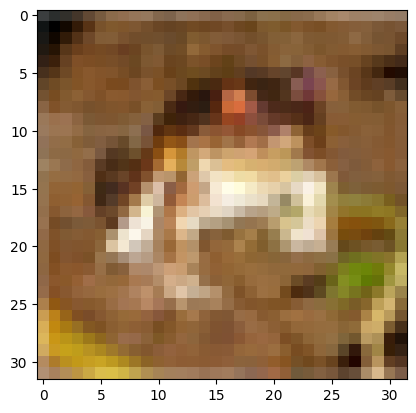

In [59]:
image = x_train[0]
plt.imshow(image)
plt.show()

In [81]:
history = model.fit(x_train, y_train, batch_size=32, epochs=20, validation_split=0.2)

Epoch 1/20


I0000 00:00:1774017702.117735    1242 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_595031__.13


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.3160 - loss: 1.8946 - val_accuracy: 0.3614 - val_loss: 1.7695
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.3892 - loss: 1.7044 - val_accuracy: 0.3999 - val_loss: 1.6790
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.4164 - loss: 1.6229 - val_accuracy: 0.4111 - val_loss: 1.6693
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4378 - loss: 1.5727 - val_accuracy: 0.4337 - val_loss: 1.6010
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4514 - loss: 1.5346 - val_accuracy: 0.4338 - val_loss: 1.5985
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4606 - loss: 1.5083 - val_accuracy: 0.4263 - val_loss: 1.6214
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4712 - loss: 1.4799 - val_accuracy: 0.4405 - val_loss: 1.5709
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4791 - loss: 1.4565 - val_accurac

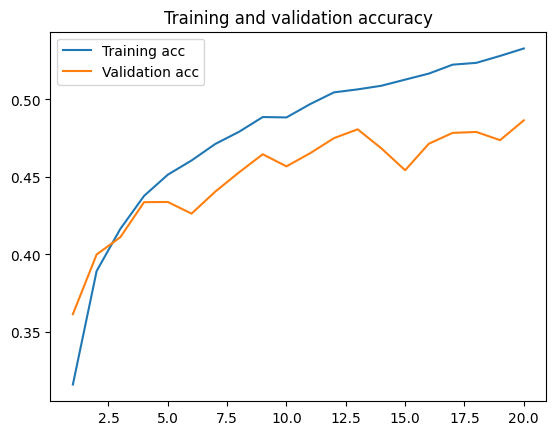

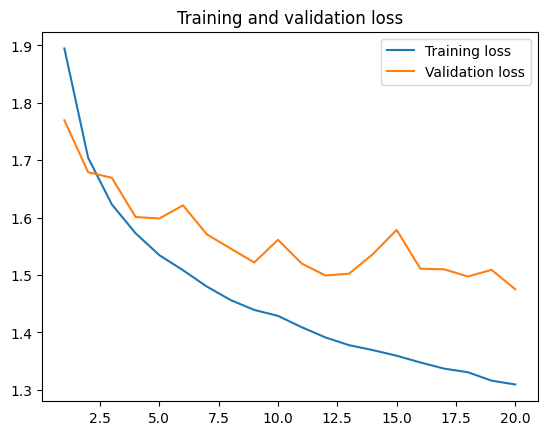

In [82]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs, acc, label='Training acc')
plt.plot(epochs, val_acc, label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [83]:
test_scores = model.evaluate(x_test, y_test, verbose=1)
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4905 - loss: 1.4575
Test loss: 1.4574538469314575
Test accuracy: 0.49050000309944153


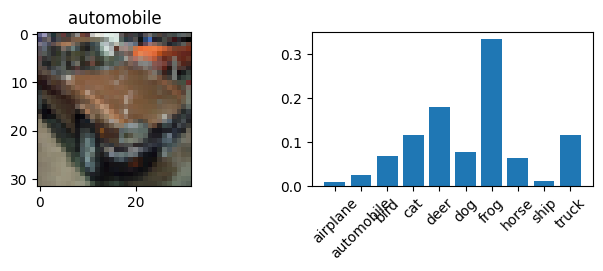

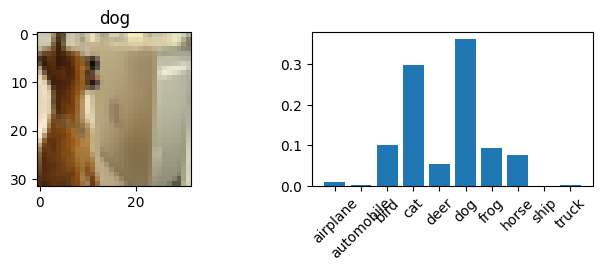

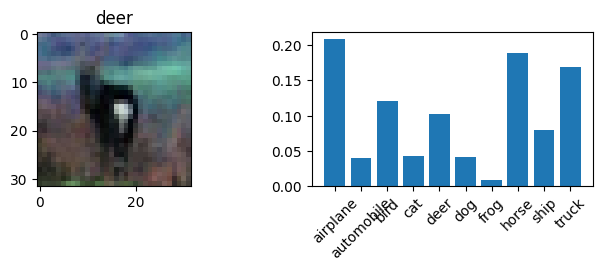

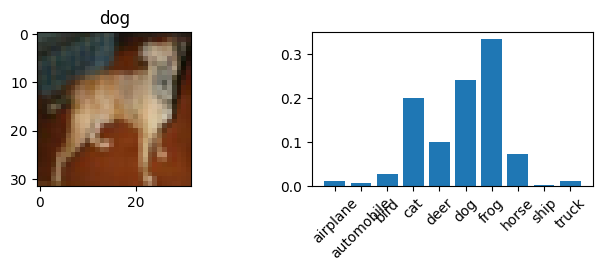

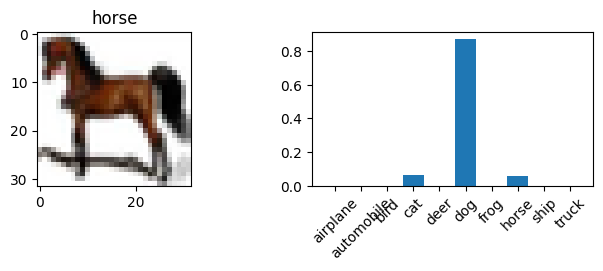

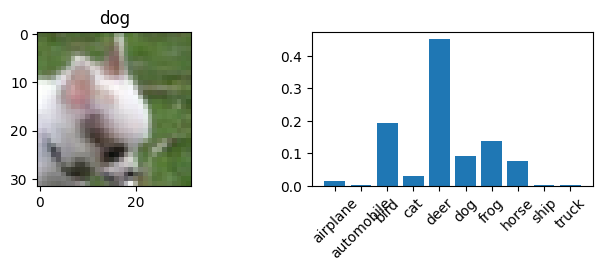

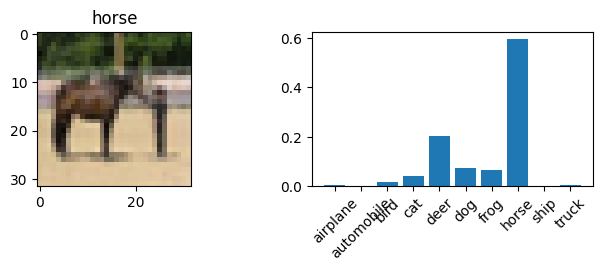

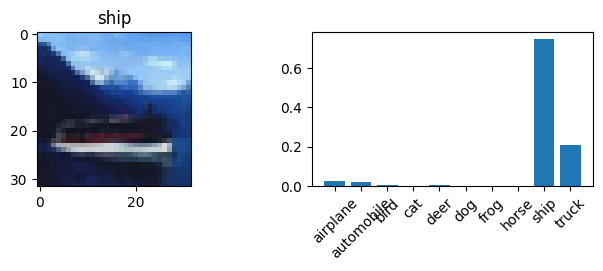

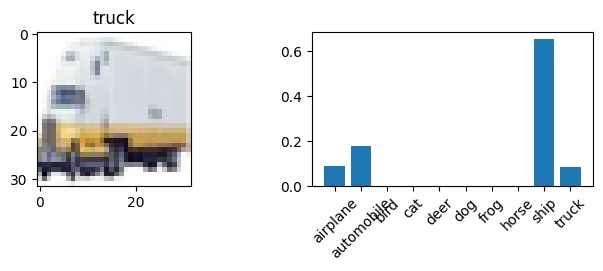

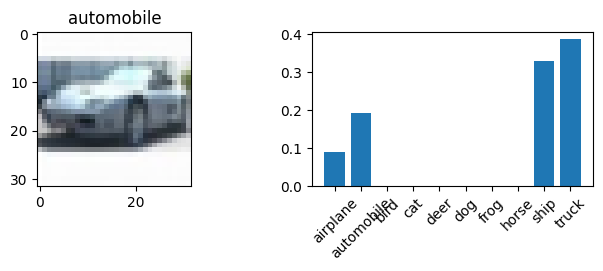

In [84]:
x = x_test
y = model(x)
start = 2000

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

for k in range(10):
    plt.figure(figsize=(8,2))
    plt.subplot(1,2,1)
    plt.imshow(x_test[start+k])
    plt.title(class_names[y_test[start+k][0]])

    plt.subplot(1,2,2)
    plt.bar(range(10), y[start+k].numpy().flatten())
    plt.xticks(range(10), class_names, rotation=45)